In [68]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Configuration

In [69]:
# File paths
INPUT_JST_DATA_PATH = './Source/JSTdatasetR6.xlsx'
INPUT_MARKET_CAP_WEIGHTS_PATH = '../Market Caps/Final/coalesced_market_cap_weights.csv'
OUTPUT_JST_RETURN_DATA_PATH = './Processed/jst_return_data.csv'
OUTPUT_EQUITIES_UNIVERSE_PATH = './Processed/equities_universe.csv'
OUTPUT_BONDS_UNIVERSE_PATH = './Processed/bonds_universe.csv'
OUTPUT_DOMESTIC_MASK_PATH = './Processed/domestic_mask.csv'
OUTPUT_BOND_WEIGHTS_PATH = './Processed/bond_weights.csv'

# Data filtering thresholds
MAX_MARKET_CAP_THRESHOLD = 0.2
MAX_DEFLATION_THRESHOLD = 0.5

# Plot parameters
PLOT_YEAR_MIN = 1870
PLOT_YEAR_MAX = 2020
FIGSIZE_PERIODS = (12, 10)
FIGSIZE_DEBT_WEIGHTS = (12, 5)
FIGSIZE_CUM_RETURNS = (12, 6)
BAR_HEIGHT = 0.8
GRID_ALPHA = 0.3
STACKPLOT_LINE_WIDTH = 0.5
LINE_WIDTH = 1
FONTSIZE_LABEL = 12
FONTSIZE_TITLE_SMALL = 13
FONTSIZE_TITLE_LARGE = 14
FONTSIZE_LEGEND = 9
TITLE_PAD = 15
BONDS_WEIGHTS_OUTPUT_PATH = '../../../Figs/bond_weights.png'
COUNTRY_AVAILABILITY_OUTPUT_PATH = '../../../Figs/country_availability.png'

# Quality check tolerances
WEIGHT_SUM_TOLERANCE_MIN = 0.999
WEIGHT_SUM_TOLERANCE_MAX = 1.001

# GDP scaling factors by country (for debt calculations)
GDP_SCALING = {
    "AUS": 1e6,
    "BEL": 1e6,
    "CAN": 1e9,
    "DNK": 1e9,
    "FIN": 1e6,
    "FRA": 1e9,
    "DEU": 1e9,
    "IRL": 1e6,
    "ITA": 1e9,
    "JPN": 1e12,
    "NLD": 1e6,
    "NOR": 1e6,
    "PRT": 1e6,
    "ESP": 1e6,
    "SWE": 1e6,
    "CHE": 1e6,
    "GBR": 1e9,
    "USA": 1e9,
}

# Country list
JST_COUNTRIES = [
    "AUS", "BEL", "CAN", "DNK", "FIN", "FRA", "DEU", "IRL", "ITA",
    "JPN", "NLD", "NOR", "PRT", "ESP", "SWE", "CHE", "GBR", "USA",
]

# Data Loading

In [70]:
# load data
jst_data = pl.read_excel(INPUT_JST_DATA_PATH)

# load in market cap weights
equity_weights = pl.read_csv(
    INPUT_MARKET_CAP_WEIGHTS_PATH
).rename({"Country": "iso", "Year": "year", "Percentage": "weight"})


Could not determine dtype for column 44, falling back to string
Could not determine dtype for column 45, falling back to string
Could not determine dtype for column 51, falling back to string
Could not determine dtype for column 52, falling back to string
Could not determine dtype for column 53, falling back to string


In [71]:
# Generate country color mapping
colors_map = plt.cm.tab20(np.linspace(0, 1, len(JST_COUNTRIES)))
country_colors = {country: colors_map[i] for i, country in enumerate(JST_COUNTRIES)}

# Data Processing

In [72]:
# calculate currency returns
c_ret = (
    jst_data.select("year", "iso", "xrusd")
    .sort("iso","year")
    .with_columns(
        pl.col("xrusd").pct_change().over("iso").alias("xrusd_return")
    )
    .filter(pl.col("xrusd_return").is_not_null())
    .select("year", "iso", "xrusd_return")
)


returns_usd = jst_data.join(
    c_ret,
    on=["year", "iso"],
    how="inner"
).select(
    "year",
    "iso",
    "xrusd_return",
    ((1 + pl.col("eq_tr")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("eq_tr_usd"),
    ((1 + pl.col("bond_tr")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("bond_tr_usd"),
    ((1 + pl.col("bill_rate")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("bill_rate_usd")
)

jst_return_data = jst_data.select(
    "year", "iso", "eq_tr", "bond_tr", "bill_rate", "cpi", "xrusd"
).join(
    returns_usd.select("year", "iso", "eq_tr_usd", "bond_tr_usd", "bill_rate_usd", "xrusd_return"),
    on=["year", "iso"],
    how="left"
).sort("iso","year").with_columns(
    pl.col("cpi").pct_change().over("iso").alias("cpi_return")
)

# write out the combined data for reference
jst_return_data.write_csv("./Processed/jst_return_data.csv")

mask_data = jst_return_data.join(
    equity_weights.rename({"weight": "equity_weight"}),
    on=["year", "iso"],
    how="left"
)

# can be "domestic" if: has eq_tr, bond_tr, cpi, and bill_rate AND xrusd is not null
domestic_mask = jst_return_data.join(
    equity_weights.rename({"weight": "equity_weight"}),
    on=["year", "iso"],
    how="left"
).filter(
    pl.col("eq_tr").is_not_null() &
    pl.col("bond_tr").is_not_null() &
    pl.col("bill_rate").is_not_null() &
    pl.col("cpi_return").is_not_null() &
    pl.col("xrusd_return").is_not_null() &
    (pl.col("equity_weight") <= MAX_MARKET_CAP_THRESHOLD)
).select(
    "year", "iso"
).sort("iso", "year")

# can be considered "foreign equity" if: has eq_tr and xrusd is not null
foreign_equity_mask = jst_return_data.filter(
    pl.col("eq_tr").is_not_null() &
    pl.col("xrusd_return").is_not_null() &
    (pl.col("xrusd_return") < MAX_DEFLATION_THRESHOLD) # Exclude deflationary crisis
).select(
    "year", "iso"
).sort("iso", "year")

# can be considered "foreign bond" if: has bond_tr and xrusd is not null
foreign_bond_mask = jst_return_data.filter(
    pl.col("bond_tr").is_not_null() &
    pl.col("xrusd_return").is_not_null() &
    (pl.col("xrusd_return") < MAX_DEFLATION_THRESHOLD) # Exclude deflationary crisis
).select(
    "year", "iso"
).sort("iso", "year")


# Analyze Periods & Create Universes

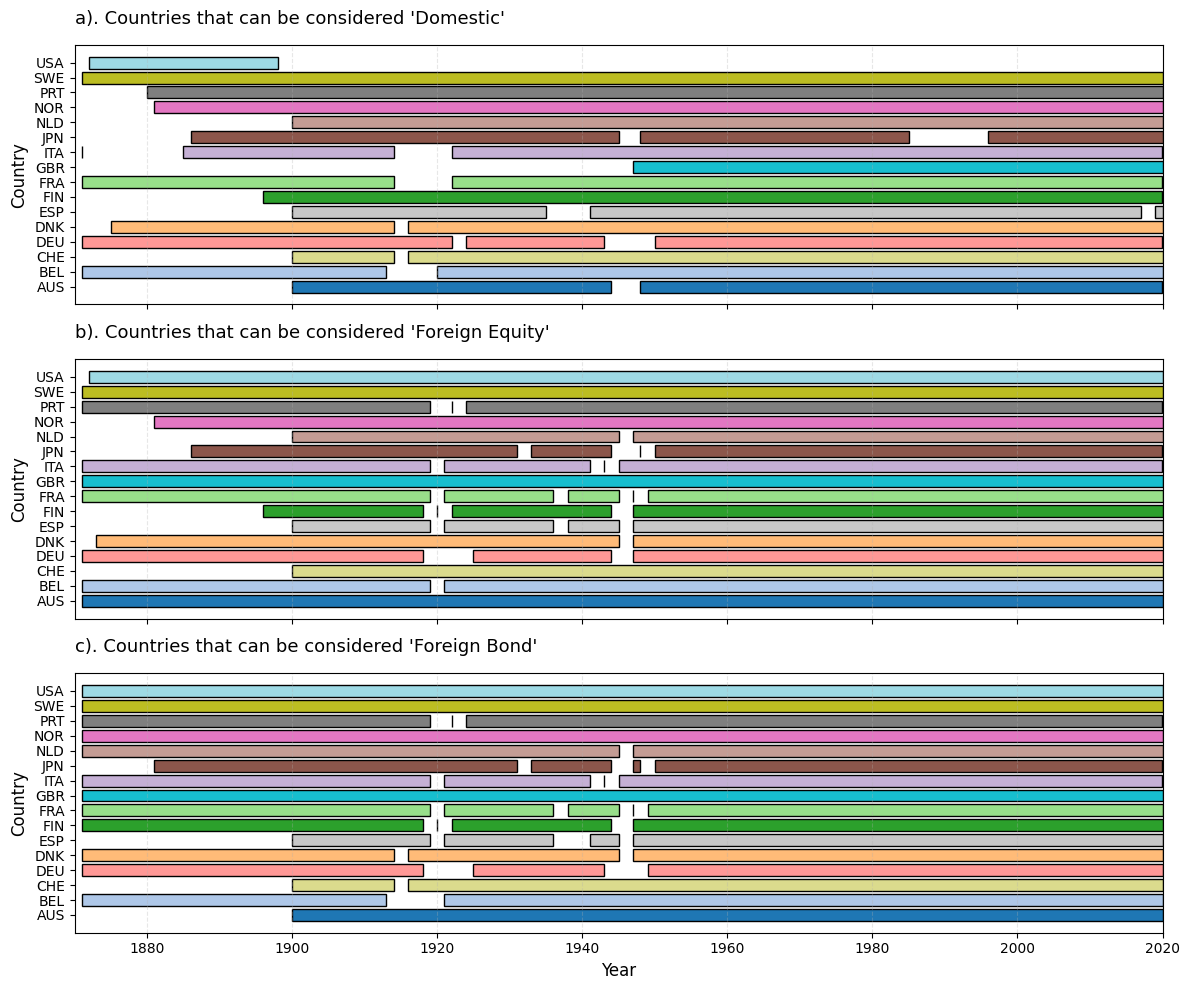


Domestic - Countries with discontinuities:
  AUS: 2 periods
    1900 - 1944
    1948 - 2020
  BEL: 2 periods
    1871 - 1913
    1920 - 2020
  CHE: 2 periods
    1900 - 1914
    1916 - 2020
  DEU: 3 periods
    1871 - 1922
    1924 - 1943
    1950 - 2020
  DNK: 2 periods
    1875 - 1914
    1916 - 2020
  ESP: 3 periods
    1900 - 1935
    1941 - 2017
    2019 - 2020
  FRA: 2 periods
    1871 - 1914
    1922 - 2020
  ITA: 3 periods
    1871 - 1871
    1885 - 1914
    1922 - 2020
  JPN: 3 periods
    1886 - 1945
    1948 - 1985
    1996 - 2020

Foreign Equity - Countries with discontinuities:
  BEL: 2 periods
    1871 - 1919
    1921 - 2020
  DEU: 3 periods
    1871 - 1918
    1925 - 1944
    1947 - 2020
  DNK: 2 periods
    1873 - 1945
    1947 - 2020
  ESP: 4 periods
    1900 - 1919
    1921 - 1936
    1938 - 1945
    1947 - 2020
  FIN: 4 periods
    1896 - 1918
    1920 - 1920
    1922 - 1944
    1947 - 2020
  FRA: 5 periods
    1871 - 1919
    1921 - 1936
    1938 - 1945
    1947 - 

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_23696\2383492283.py:107: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  ]).str.concat(", ")


In [73]:
# Calculate continuous time periods for each mask, handling discontinuities
def calculate_periods(mask_data):
    """
    Identify continuous time periods for each country, handling gaps in the data.
    Returns a DataFrame with iso, start_year, end_year for each continuous period.
    """
    periods = (
        mask_data
        .sort("iso", "year")
        # Calculate previous year within each country
        .with_columns(
            pl.col("year").shift(1).over("iso").alias("prev_year")
        )
        # Flag discontinuities (where year - prev_year > 1)
        .with_columns(
            ((pl.col("year") - pl.col("prev_year")) > 1).fill_null(True).alias("is_new_period")
        )
        # Create period group by cumsum of discontinuity flags
        .with_columns(
            pl.col("is_new_period").cum_sum().over("iso").alias("period_group")
        )
        # Group by country and period to get start/end years
        .group_by(["iso", "period_group"]).agg([
            pl.col("year").min().alias("start_year"),
            pl.col("year").max().alias("end_year")
        ])
        .sort("iso", "start_year")
    )
    return periods

domestic_periods = calculate_periods(domestic_mask)
foreign_equity_periods = calculate_periods(foreign_equity_mask)
foreign_bond_periods = calculate_periods(foreign_bond_mask)

# Create figure with 3 subplots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_PERIODS, sharex=True)

# Helper function to plot bars with support for multiple periods per country
def plot_periods(ax, periods, title):
    # Get unique countries to determine y-axis positions
    unique_countries = sorted(periods["iso"].unique().to_list())
    country_to_idx = {country: idx for idx, country in enumerate(unique_countries)}
    
    for row in periods.iter_rows(named=True):
        country = row["iso"]
        start = row["start_year"]
        end = row["end_year"]
        duration = end - start
        idx = country_to_idx[country]
        
        # Use consistent color for each country
        color = country_colors.get(country, "gray")
        ax.barh(idx, duration, left=start, height=BAR_HEIGHT, edgecolor="black", color=color)
    
    ax.set_yticks(range(len(unique_countries)))
    ax.set_yticklabels(unique_countries)
    ax.set_ylabel("Country", fontsize=FONTSIZE_LABEL)
    ax.set_title(title, fontsize=FONTSIZE_TITLE_SMALL, pad=TITLE_PAD, loc="left")
    ax.grid(True, alpha=GRID_ALPHA, axis='x', linestyle='--')
    ax.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)

# Plot each mask
plot_periods(axes[0], domestic_periods, "a). Countries that can be considered 'Domestic'")
plot_periods(axes[1], foreign_equity_periods, "b). Countries that can be considered 'Foreign Equity'")
plot_periods(axes[2], foreign_bond_periods, "c). Countries that can be considered 'Foreign Bond'")
    
# Only show xlabel on bottom subplot
axes[2].set_xlabel("Year", fontsize=FONTSIZE_LABEL)

plt.tight_layout()
plt.savefig(COUNTRY_AVAILABILITY_OUTPUT_PATH, dpi=300)
plt.show()

# Print summary of discontinuities
for name, periods_df in [("Domestic", domestic_periods), 
                         ("Foreign Equity", foreign_equity_periods), 
                         ("Foreign Bond", foreign_bond_periods)]:
    multi_period_countries = (
        periods_df.group_by("iso")
        .agg(pl.col("period_group").count().alias("num_periods"))
        .filter(pl.col("num_periods") > 1)
    )
    if len(multi_period_countries) > 0:
        print(f"\n{name} - Countries with discontinuities:")
        for country in multi_period_countries["iso"].to_list():
            country_periods = periods_df.filter(pl.col("iso") == country)
            print(f"  {country}: {len(country_periods)} periods")
            for p in country_periods.iter_rows(named=True):
                print(f"    {p['start_year']} - {p['end_year']}")
    else:
        print(f"\n{name} - No discontinuities found")

# Display the periods as a table (handling multiple periods per country)
def format_periods(periods_df):
    """Format periods for each country, handling discontinuities."""
    return (
        periods_df
        .sort("iso", "start_year")
        .group_by("iso")
        .agg(
            pl.concat_str([
                pl.col("start_year").cast(pl.Utf8), 
                pl.lit("--"), 
                pl.col("end_year").cast(pl.Utf8)
            ]).str.concat(", ")
        )
    )

dp = format_periods(domestic_periods).rename({"iso": "Country Code", "start_year": "Domestic Availability"})
fep = format_periods(foreign_equity_periods).rename({"iso": "Country Code", "start_year": "Foreign Equity Availability"})
fbp = format_periods(foreign_bond_periods).rename({"iso": "Country Code", "start_year": "Foreign Bond Availability"})

# Get all unique countries
all_countries = sorted(set(
    dp["Country Code"].to_list() + 
    fep["Country Code"].to_list() + 
    fbp["Country Code"].to_list()
))

# Create base dataframe with all countries
report = pl.DataFrame({"Country Code": all_countries})

# Join all availability data
report = (
    report
    .join(dp, on="Country Code", how="left")
    .join(fep, on="Country Code", how="left")
    .join(fbp, on="Country Code", how="left")
    .fill_null("--")
)

print("\n" + "="*80)
print(report.to_pandas().to_latex(index=False, column_format='lccc'))
print("="*80)

In [74]:
equities_universe = domestic_mask.select(
    pl.col("year"),
    pl.col("iso").alias("iso_domestic")
).join(
    foreign_equity_mask.select(
        pl.col("year"),
        pl.col("iso").alias("iso_foreign")
    ),
    on="year",
    how="inner",
).filter(
    pl.col("iso_domestic") != pl.col("iso_foreign")
)

bonds_universe = domestic_mask.select(
    pl.col("year"),
    pl.col("iso").alias("iso_domestic")
).join(
    foreign_bond_mask.select(
        pl.col("year"),
        pl.col("iso").alias("iso_foreign")
    ),
    on="year",
    how="inner",
).filter(
    pl.col("iso_domestic") != pl.col("iso_foreign")
)

# write out the universes
equities_universe.write_csv(OUTPUT_EQUITIES_UNIVERSE_PATH)
bonds_universe.write_csv(OUTPUT_BONDS_UNIVERSE_PATH)
domestic_mask.write_csv(OUTPUT_DOMESTIC_MASK_PATH)

# Government Debt Weights

In [75]:
gov_debt = (jst_data
    .select(
        pl.col("year"),
        pl.col("iso"),
        pl.col("gdp"),
        pl.col("debtgdp"),
        pl.col("xrusd")
    )
    .with_columns(
        pl.col("iso").replace(GDP_SCALING, default=1.0).alias("scaling_factor")
    )
    .with_columns(
        ((pl.col("gdp") * pl.col("scaling_factor") * pl.col("debtgdp")) / pl.col("xrusd")).alias("debt")
    )
    .select("year", "iso", "debt")
    .sort("year")
    .with_columns(
        pl.col("debt").forward_fill().over(pl.col("iso"))
    )
)

bond_debt = foreign_bond_mask.join(gov_debt, on=["year", "iso"], how="inner")


bond_shares = bond_debt.with_columns(
    (pl.col("debt") /  pl.col("debt").sum().over("year")).alias("debt_share")
).select(
    "year", "iso", "debt_share"
)


C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_23696\3399196378.py:10: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("iso").replace(GDP_SCALING, default=1.0).alias("scaling_factor")


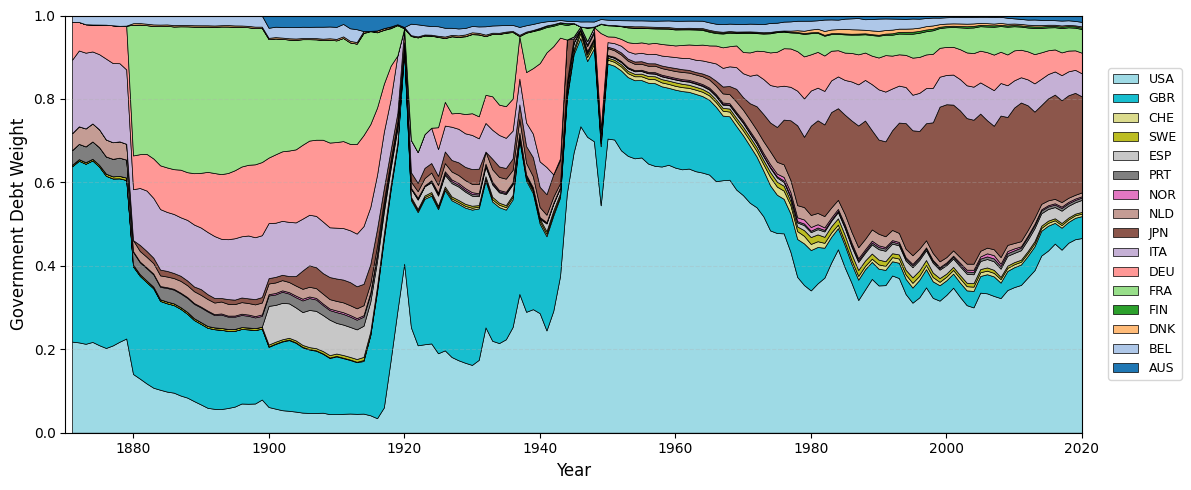


=== Bond Weight Quality Checks ===

1. Yearly weight sums:
   Min: 1.000000
   Max: 1.000000
   Mean: 1.000000
   [OK] All years sum to 1.0

2. Year coverage: 1871 to 2020
   Total years: 150

3. Countries in bond universe:
shape: (16, 3)
┌─────┬────────────┬───────┐
│ iso ┆ avg_weight ┆ years │
│ --- ┆ ---        ┆ ---   │
│ str ┆ f64        ┆ u32   │
╞═════╪════════════╪═══════╡
│ USA ┆ 0.315327   ┆ 150   │
│ GBR ┆ 0.182802   ┆ 150   │
│ FRA ┆ 0.132371   ┆ 146   │
│ JPN ┆ 0.106293   ┆ 136   │
│ DEU ┆ 0.096841   ┆ 139   │
│ …   ┆ …          ┆ …     │
│ CHE ┆ 0.007848   ┆ 120   │
│ SWE ┆ 0.00679    ┆ 150   │
│ DNK ┆ 0.003632   ┆ 148   │
│ NOR ┆ 0.003483   ┆ 150   │
│ FIN ┆ 0.002033   ┆ 146   │
└─────┴────────────┴───────┘


In [76]:
# Visualize Government Debt Weights Over Time
fig, ax = plt.subplots(figsize=FIGSIZE_DEBT_WEIGHTS)

# Pivot to wide format for stacked area plot
pivoted = (
    bond_shares
    .pivot(index="year", on="iso", values="debt_share")
    .sort("year")
    .fill_null(0)
)

# Get all countries present in the data
countries_in_data = [col for col in pivoted.columns if col != "year"]

# sort like the JST_COUNTRIES list, with any missing countries at the end
countries_in_data = sorted(countries_in_data, key=lambda x: -JST_COUNTRIES.index(x) if x in JST_COUNTRIES else len(JST_COUNTRIES))

# Map countries to their colors
colors = [country_colors[country] for country in countries_in_data]

# Create stacked area plot
ax.stackplot(
    pivoted["year"], 
    [pivoted[country] for country in countries_in_data],
    labels=countries_in_data,
    colors=colors,
    edgecolor='black',
    linewidth=STACKPLOT_LINE_WIDTH
)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=FONTSIZE_LEGEND, ncol=1)
ax.set_xlabel("Year", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Government Debt Weight", fontsize=FONTSIZE_LABEL)
# ax.set_title("Government Debt Weights by Country (Foreign Bond Universe)", fontsize=FONTSIZE_TITLE_LARGE, pad=TITLE_PAD)
ax.grid(True, alpha=GRID_ALPHA, axis='y', linestyle='--')
ax.set_ylim(0, 1)
ax.set_xlim(PLOT_YEAR_MIN, PLOT_YEAR_MAX)

plt.tight_layout()
plt.savefig(BONDS_WEIGHTS_OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

# Quality checks
print("\n=== Bond Weight Quality Checks ===\n")

yearly_sums = bond_shares.group_by("year").agg(pl.col("debt_share").sum().alias("total"))
print(f"1. Yearly weight sums:")
print(f"   Min: {yearly_sums['total'].min():.6f}")
print(f"   Max: {yearly_sums['total'].max():.6f}")
print(f"   Mean: {yearly_sums['total'].mean():.6f}")

problematic_years = yearly_sums.filter((pl.col("total") < WEIGHT_SUM_TOLERANCE_MIN) | (pl.col("total") > WEIGHT_SUM_TOLERANCE_MAX))
if len(problematic_years) > 0:
    print(f"   WARNING: {len(problematic_years)} years with totals outside [{WEIGHT_SUM_TOLERANCE_MIN}, {WEIGHT_SUM_TOLERANCE_MAX}]")
else:
    print("   [OK] All years sum to 1.0")

print(f"\n2. Year coverage: {bond_shares['year'].min()} to {bond_shares['year'].max()}")
print(f"   Total years: {bond_shares['year'].n_unique()}")

print(f"\n3. Countries in bond universe:")
country_stats = bond_shares.group_by("iso").agg([
    pl.col("debt_share").mean().alias("avg_weight"),
    pl.col("year").count().alias("years")
]).sort("avg_weight", descending=True)
print(country_stats)

# write out the final bond shares data
bond_shares.filter(pl.col("debt_share").is_not_null()).write_csv(OUTPUT_BOND_WEIGHTS_PATH)

In [77]:
# calculate currency returns
c_ret = (
    jst_data.select("year", "iso", "xrusd")
    .sort("iso","year")
    .with_columns(
        pl.col("xrusd").pct_change().over("iso").alias("xrusd_return")
    )
    .filter(pl.col("xrusd_return").is_not_null())
    .select("year", "iso", "xrusd_return")
)





# Cumulative Returns Analysis

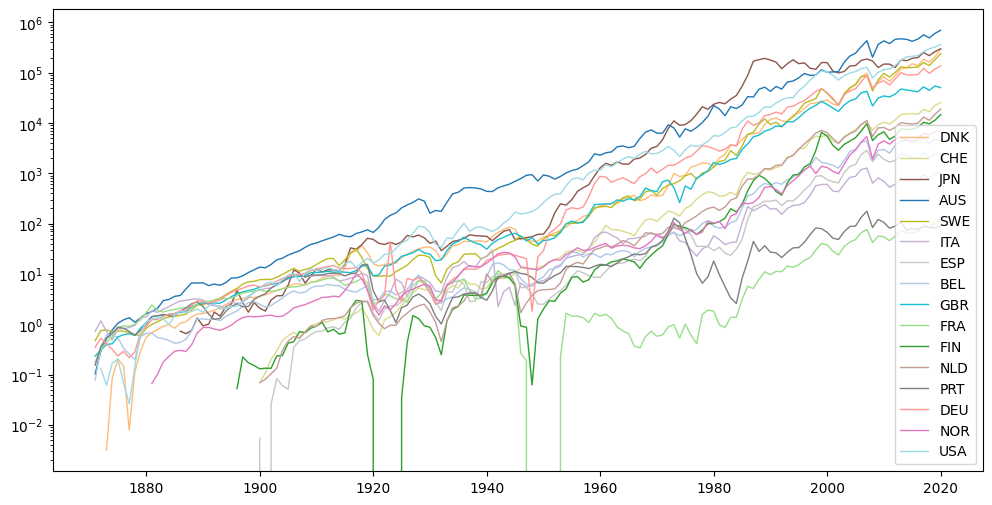

In [78]:
returns_usd = jst_data.join(
    c_ret,
    on=["year", "iso"],
    how="inner"
).select(
    "year",
    "iso",
    "xrusd_return",
    ((1 + pl.col("eq_tr")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("eq_tr_usd"),
    ((1 + pl.col("bond_tr")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("bond_tr_usd"),
    ((1 + pl.col("bill_rate")) * (1 + pl.col("xrusd_return"))**-1 - 1).alias("bill_rate_usd")
)

cum_eq_tr_usd = returns_usd.filter(pl.col("eq_tr_usd").is_not_null()).with_columns(
    ((pl.col("eq_tr_usd")+1).cum_prod()-1).over("iso").alias("cum_eq_tr_usd"),
    "year",
    "iso"
)

fig, ax = plt.subplots(figsize=FIGSIZE_CUM_RETURNS)

for iso in cum_eq_tr_usd["iso"].unique():
    # if iso == "DEU":
    #     continue
    iso_data = cum_eq_tr_usd.filter(pl.col("iso") == iso)
    colour = country_colors[iso] if iso in country_colors else "gray"
    ax.plot(iso_data["year"], iso_data["cum_eq_tr_usd"], label=iso, color=colour, linewidth=LINE_WIDTH)

ax.legend()
ax.set_yscale("log")
# cum_eq_tr_usd.write_csv("data/cum_eq_tr_usd.csv")